# Lab 2: Estadística Descriptiva Básica 2

---
## Parte 1: Series de Tiempo — EUR/USD

### Paso 1 — Leer el dataset desde GitHub

Dataset: precio EUR/USD desde 05/07/2022 hasta 12/05/2023 con periodicidad de 1 hora.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


### Paso 2 — Definir la columna 'time' como índice

In [40]:
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')
df.head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


### Paso 3 — Obtener información del DataFrame

In [41]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB


In [42]:
df.describe()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,1.043891,1.044815,1.042991,1.043906,3690.249400,8.981600,0.0,1.043898,0.000012,0.000012,0.000012
std,1443.520003,0.041135,0.040991,0.041263,0.041135,2800.488505,5.785115,0.0,0.041129,0.001400,0.001404,0.000978
min,0.000000,0.953910,0.955930,0.953570,0.953910,85.000000,0.000000,0.0,0.954735,-0.013970,-0.014010,-0.007260
25%,1249.750000,1.002718,1.003507,1.001715,1.002705,1738.750000,8.000000,0.0,1.002648,-0.000580,-0.000600,-0.000425
50%,2499.500000,1.055670,1.056795,1.054960,1.055700,2999.500000,8.000000,0.0,1.055712,-0.000005,0.000000,0.000005
75%,3749.250000,1.078940,1.079582,1.078222,1.078947,4861.000000,8.000000,0.0,1.078955,0.000620,0.000612,0.000430
max,4999.000000,1.108470,1.109530,1.108050,1.108500,23708.000000,183.000000,0.0,1.108280,0.017340,0.017420,0.010780


In [43]:
print('Shape:', df.shape)
print('Dtypes:')
print(df.dtypes)

Shape: (5000, 12)
Dtypes:
Unnamed: 0              int64
open                  float64
high                  float64
low                   float64
close                 float64
tick_volume             int64
spread                  int64
real_volume             int64
MeanCloseOpen         float64
Diff_Close            float64
Diff_Open             float64
Diff_MeanCloseOpen    float64
dtype: object


### Paso 4 — Verificar valores nulos o NaN

In [44]:
print('Nulos por columna (isnull):')
print(df.isnull().sum())
print('\nNulos por columna (isna):')
print(df.isna().sum())
print('\n¿Alguna columna con nulos?')
print(df.isnull().any())

Nulos por columna (isnull):
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64

Nulos por columna (isna):
Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64

¿Alguna columna con nulos?
Unnamed: 0            False
open                  False
high                  False
low                   False
close                 False
tick_volume           False
spread                False
real_volume           False
MeanCloseOpen         False
Diff_Close            False
Diff_Open             False
Diff_Me

### Paso 5 — Notación PascalCase y seleccionar solo la columna Close

In [45]:
# Ver columnas actuales
print('Columnas originales:', df.columns.tolist())

# Renombrar a PascalCase
df.columns = [col.strip().title().replace(' ', '') for col in df.columns]
print('Columnas PascalCase:', df.columns.tolist())

# Quedarse solo con la columna Close
df = df[['Close']]
df.head()

Columnas originales: ['Unnamed: 0', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'MeanCloseOpen', 'Diff_Close', 'Diff_Open', 'Diff_MeanCloseOpen']
Columnas PascalCase: ['Unnamed:0', 'Open', 'High', 'Low', 'Close', 'Tick_Volume', 'Spread', 'Real_Volume', 'Meancloseopen', 'Diff_Close', 'Diff_Open', 'Diff_Meancloseopen']


,Close
time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181


### Paso 6: Diferencia de precio y ajuste de distribucion estadistica

# Paso 6a — Calcular DiffPrice (diferencia de precio entre horas)

In [46]:
df['DiffPrice'] = df['Close'].diff()
df = df.dropna()  # Eliminar el primer NaN generado por diff()
print('Columnas:', df.columns.tolist())
print('Shape:', df.shape)
df.head()

Columnas: ['Close', 'DiffPrice']
Shape: (4999, 2)


,Close,DiffPrice
time,,
2022-07-25 14:00:00,1.02299,-0.00046
2022-07-25 15:00:00,1.02457,0.00158
2022-07-25 16:00:00,1.02485,0.00028
2022-07-25 17:00:00,1.02181,-0.00304
2022-07-25 18:00:00,1.02099,-0.00082


### Paso 6b — Histograma de DiffPrice

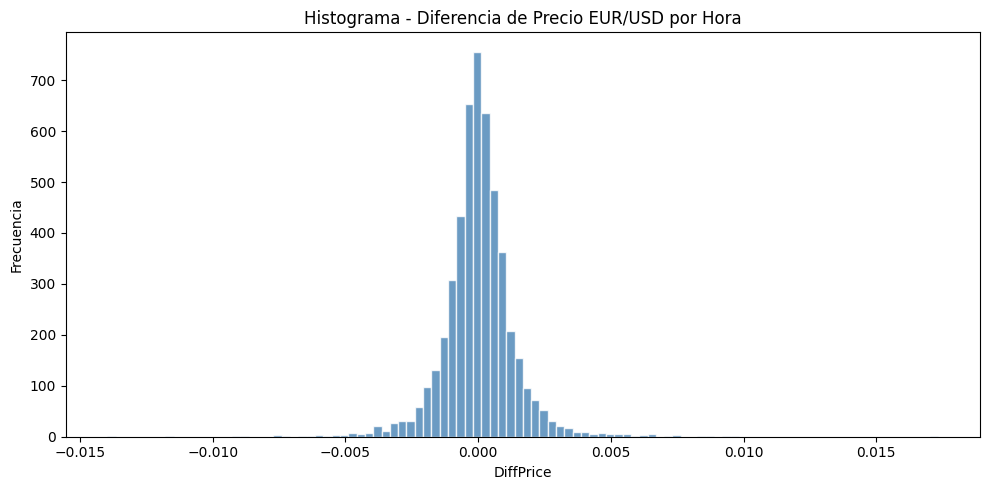

In [47]:
plt.figure(figsize=(10, 5))
plt.hist(df['DiffPrice'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
plt.title('Histograma - Diferencia de Precio EUR/USD por Hora')
plt.xlabel('DiffPrice')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### Paso 6c — Ajuste de distribución estadística con Fitter


,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
lognorm,106500.661168,-51509.765589,-51490.214609,0.101912,0.091597,5.996555e-37
beta,106677.525909,-51503.229672,-51477.161699,0.102011,0.090756,2.794092e-36
norm,106744.023571,-51505.717419,-51492.683433,0.102054,0.090533,4.194767e-36
burr,721804.561088,-37765.252892,-37739.184919,7.480557,0.386409,0.000000e+00
gamma,923360.482403,-17723.242274,-17703.691294,14.865645,0.591356,0.000000e+00


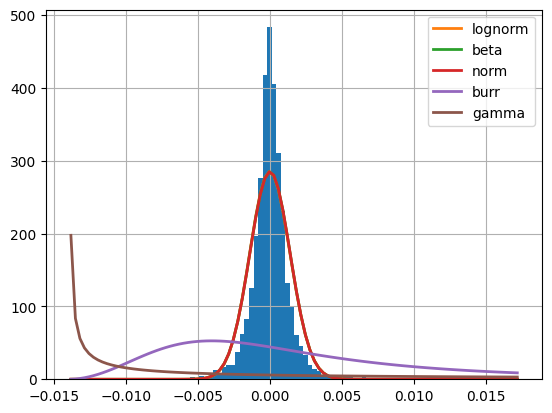

In [48]:
from fitter import Fitter, get_common_distributions, get_distributions

data_fitter = df['DiffPrice'].dropna().values

f = Fitter(data_fitter,
           distributions=['gamma', 'lognorm', 'beta', 'burr', 'norm'])
f.fit()
f.summary()

In [49]:
# Mejor distribución por suma de errores cuadráticos
print('Mejor distribución:', f.get_best(method='sumsquare_error'))

# Parámetros de la distribución beta
print('Parámetros beta:', f.fitted_param['beta'])

Mejor distribución: {'lognorm': {'s': np.float64(0.009509964461157715), 'loc': np.float64(-0.1471693008245066), 'scale': np.float64(0.14717494036949658)}}
Parámetros beta: (np.float64(14613.868594375072), np.float64(27361.660606098114), np.float64(-0.2096488866774875), np.float64(0.6022115067129248))


### Paso 7 — Seleccionar solo los datos del año 2023

In [50]:
df_2023 = df.loc['2023-01-01':'2023-12-31']
print('Shape df_2023:', df_2023.shape)
df_2023.head()

Shape df_2023: (2278, 2)


,Close,DiffPrice
time,,
2023-01-02 00:00:00,1.06796,-0.00200
2023-01-02 01:00:00,1.06965,0.00169
2023-01-02 02:00:00,1.07058,0.00093
2023-01-02 03:00:00,1.06896,-0.00162
2023-01-02 04:00:00,1.06880,-0.00016


### Paso 8 — Promedios con groupby: 15 días, semanal y mensual

In [51]:
# Promedio cada 15 días
df_15d = df.groupby(pd.Grouper(freq='15D')).mean()
print('Periodicidad 15 días:')
print(df_15d.head())

Periodicidad 15 días:
               Close  DiffPrice
time                           
2022-07-25  1.019586  -0.000017
2022-08-09  1.016159  -0.000086
2022-08-24  0.996934   0.000015
2022-09-08  0.999753  -0.000065
2022-09-23  0.976675  -0.000035


In [52]:
# Promedio semanal
df_1w = df.groupby(pd.Grouper(freq='W')).mean()
print('Periodicidad semanal:')
print(df_1w.head())

Periodicidad semanal:
               Close  DiffPrice
time                           
2022-07-31  1.018250  -0.000009
2022-08-07  1.020890  -0.000038
2022-08-14  1.025295   0.000065
2022-08-21  1.015174  -0.000181
2022-08-28  0.997196  -0.000065


In [53]:
# Promedio mensual
df_1m = df.groupby(pd.Grouper(freq='ME')).mean()
print('Periodicidad mensual:')
print(df_1m)

Periodicidad mensual:
               Close  DiffPrice
time                           
2022-07-31  1.018250  -0.000009
2022-08-31  1.012731  -0.000031
2022-09-30  0.990365  -0.000048
2022-10-31  0.983698   0.000016
2022-11-30  1.019872   0.000099
2022-12-31  1.058478   0.000059
2023-01-31  1.077463   0.000031
2023-02-28  1.071167  -0.000060
2023-03-31  1.070874   0.000049
2023-04-30  1.096051   0.000036
2023-05-31  1.098980  -0.000069


### Paso 9 — Histograma por mes para datos de 2023

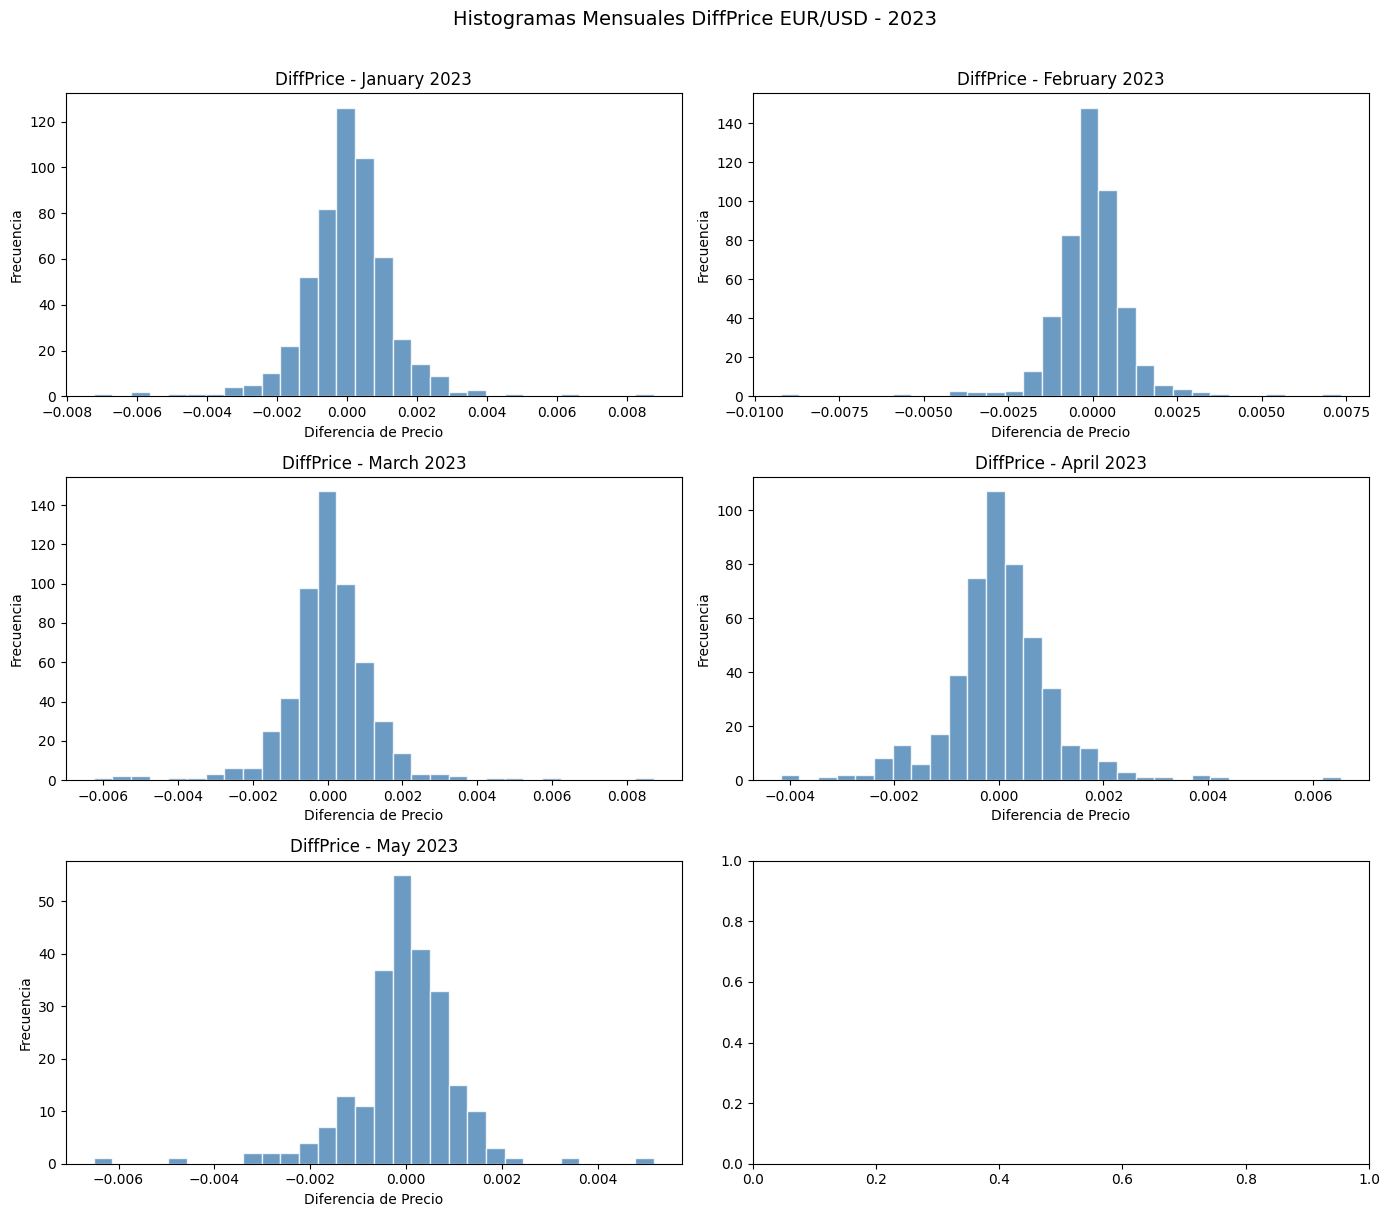

In [54]:
# Agrupar df_2023 por mes
grupos_mes = df_2023.groupby(pd.Grouper(freq='ME'))

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, group) in enumerate(grupos_mes):
    if i >= len(axes):
        break
    # CORRECCIÓN: graficar DiffPrice, no Close
    axes[i].hist(group['DiffPrice'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'DiffPrice - {name.strftime("%B %Y")}')
    axes[i].set_xlabel('Diferencia de Precio')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Histogramas Mensuales DiffPrice EUR/USD - 2023', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Parte 2: Análisis de Datos — Breast Cancer Wisconsin

Dataset: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)


### Paso 1 — Leer los datos desde una página web

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

# Leer directamente desde la web (URL oficial UCI)
url_bc = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
          'breast-cancer-wisconsin/wdbc.data')

# Nombres de columnas con la convención exacta del lab
# Las 10 características tienen 3 versiones: Mean, Se, 3 (worst)
features = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness',
            'Compactness', 'Concavity', 'ConcavePoints', 'Symmetry', 'FractalDimension']

col_names = (['Id', 'Diagnosis'] +
             [f'{f}Mean' for f in features] +
             [f'{f}Se'   for f in features] +
             [f'{f}3'    for f in features])

df = pd.read_csv(url_bc, header=None, names=col_names)

print('Shape:', df.shape)  # debe ser (569, 32)
print('Columnas:', df.columns.tolist())
df.head()

Shape: (569, 32)
Columnas: ['Id', 'Diagnosis', 'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'RadiusSe', 'TextureSe', 'PerimeterSe', 'AreaSe', 'SmoothnessSe', 'CompactnessSe', 'ConcavitySe', 'ConcavePointsSe', 'SymmetrySe', 'FractalDimensionSe', 'Radius3', 'Texture3', 'Perimeter3', 'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3', 'Symmetry3', 'FractalDimension3']


,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Paso 2 — Renombrar las columnas en formato PascalCase

Las columnas ya se crearon en PascalCase exacto del lab en el Paso 1. Solo se verifica.

In [56]:
# Las columnas ya están en PascalCase desde la lectura:
# RadiusMean, TextureMean, ... Symmetry3, FractalDimension3
print(df.columns.tolist())

# Verificar que Diagnosis tiene B y M (no 0 y 1)
print('\nValores en Diagnosis:', df['Diagnosis'].unique())

['Id', 'Diagnosis', 'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean', 'RadiusSe', 'TextureSe', 'PerimeterSe', 'AreaSe', 'SmoothnessSe', 'CompactnessSe', 'ConcavitySe', 'ConcavePointsSe', 'SymmetrySe', 'FractalDimensionSe', 'Radius3', 'Texture3', 'Perimeter3', 'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3', 'Symmetry3', 'FractalDimension3']

Valores en Diagnosis: <StringArray>
['M', 'B']
Length: 2, dtype: str


### Paso 3 — Usar head(), tail(), describe() e info()

In [57]:
# Primeras 5 filas
df.head()

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [58]:
# Últimas 5 filas
df.tail()

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [59]:
# Estadísticas descriptivas
df.describe()

,Id,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [60]:
# Tipos de datos, memoria y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Id                    569 non-null    int64  
 1   Diagnosis             569 non-null    str    
 2   RadiusMean            569 non-null    float64
 3   TextureMean           569 non-null    float64
 4   PerimeterMean         569 non-null    float64
 5   AreaMean              569 non-null    float64
 6   SmoothnessMean        569 non-null    float64
 7   CompactnessMean       569 non-null    float64
 8   ConcavityMean         569 non-null    float64
 9   ConcavePointsMean     569 non-null    float64
 10  SymmetryMean          569 non-null    float64
 11  FractalDimensionMean  569 non-null    float64
 12  RadiusSe              569 non-null    float64
 13  TextureSe             569 non-null    float64
 14  PerimeterSe           569 non-null    float64
 15  AreaSe                569 non-null

### Paso 4 — Contabilizar valores nulos (null o NaN)

In [61]:
nulos = df.isnull().sum()
print('Nulos por columna:')
print(nulos)
print(f'\nTotal de valores nulos: {nulos.sum()}')

Nulos por columna:
Id                      0
Diagnosis               0
RadiusMean              0
TextureMean             0
PerimeterMean           0
AreaMean                0
SmoothnessMean          0
CompactnessMean         0
ConcavityMean           0
ConcavePointsMean       0
SymmetryMean            0
FractalDimensionMean    0
RadiusSe                0
TextureSe               0
PerimeterSe             0
AreaSe                  0
SmoothnessSe            0
CompactnessSe           0
ConcavitySe             0
ConcavePointsSe         0
SymmetrySe              0
FractalDimensionSe      0
Radius3                 0
Texture3                0
Perimeter3              0
Area3                   0
Smoothness3             0
Compactness3            0
Concavity3              0
ConcavePoints3          0
Symmetry3               0
FractalDimension3       0
dtype: int64

Total de valores nulos: 0


### Paso 5 — Identificar valores únicos en la columna target con unique()

In [62]:
# El lab pide unique() sobre la columna con etiquetas B y M
print('Valores únicos en Diagnosis:', df['Diagnosis'].unique())
# Resultado esperado: ['M' 'B']

print('\nConteo de cada clase:')
print(df['Diagnosis'].value_counts())

Valores únicos en Diagnosis: <StringArray>
['M', 'B']
Length: 2, dtype: str

Conteo de cada clase:
Diagnosis
B    357
M    212
Name: count, dtype: int64


### Paso 6 — Conteo de casos B y M con seaborn countplot()

C:\Users\ricar\AppData\Local\Temp\ipykernel_12520\3025442441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df,


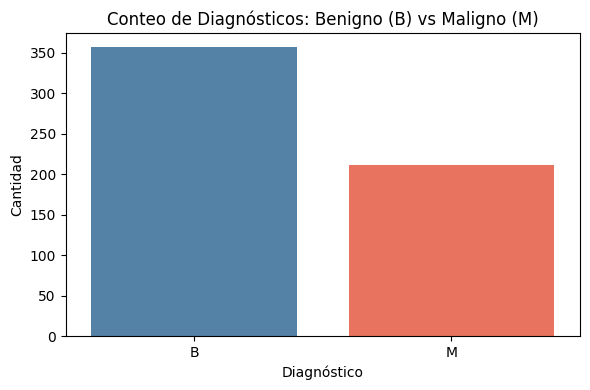

In [63]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df,
              order=['B', 'M'],
              palette={'B': 'steelblue', 'M': 'tomato'})
plt.title('Conteo de Diagnósticos: Benigno (B) vs Maligno (M)')
plt.xlabel('Diagnóstico')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

### Paso 7 — Agregar columna DiagnosisNumeric (B=0, M=1)

In [64]:
# B -> 0 (Benigno), M -> 1 (Maligno)
df['DiagnosisNumeric'] = df['Diagnosis'].map({'B': 0, 'M': 1})
df[['Diagnosis', 'DiagnosisNumeric']].head(10)

,Diagnosis,DiagnosisNumeric
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1
5,M,1
6,M,1
7,M,1
8,M,1
9,M,1


### Paso 8 — Normalizar cada columna: (x - mean(x)) / std(x)

In [65]:
# Excluir columnas no numéricas y de etiqueta
cols_excluir  = ['Id', 'Diagnosis', 'DiagnosisNumeric']
cols_features = [c for c in df.columns if c not in cols_excluir]

# Normalizar: (x - mean(x)) / std(x)
df_norm = df.copy()
df_norm[cols_features] = ((df[cols_features] - df[cols_features].mean())
                          / df[cols_features].std())

# Verificar: media ~0 y std ~1
df_norm[cols_features].describe().round(3)

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,...,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.028,-2.227,-1.983,-1.453,-3.109,-1.609,-1.114,-1.261,-2.742,-1.818,...,-1.725,-2.222,-1.692,-1.221,-2.680,-1.443,-1.305,-1.744,-2.159,-1.600
25%,-0.689,-0.725,-0.691,-0.667,-0.710,-0.746,-0.743,-0.737,-0.703,-0.722,...,-0.674,-0.748,-0.689,-0.642,-0.691,-0.680,-0.756,-0.756,-0.641,-0.691
50%,-0.215,-0.105,-0.236,-0.295,-0.035,-0.222,-0.342,-0.397,-0.072,-0.178,...,-0.269,-0.043,-0.286,-0.341,-0.047,-0.269,-0.218,-0.223,-0.127,-0.216
75%,0.469,0.584,0.499,0.363,0.636,0.493,0.526,0.646,0.530,0.471,...,0.522,0.658,0.540,0.357,0.597,0.539,0.531,0.712,0.450,0.450
max,3.968,4.648,3.973,5.246,4.767,4.564,4.240,3.924,4.481,4.907,...,4.091,3.882,4.284,5.925,3.952,5.108,4.697,2.684,6.041,6.841


### Paso 9 — Agrupar características similares con regex y startswith()


In [66]:
# Lista exacta del enunciado del lab
cols_mean = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean',
             'SmoothnessMean', 'CompactnessMean', 'ConcavityMean',
             'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean']

# --- Uso de regex para extraer prefijo alfabético (patrón del lab) ---
# re.match(r'^[a-zA-Z_]+', 'RadiusMean').group(0)  ->  'RadiusMean'
# re.match(r'^[a-zA-Z_]+', 'Radius3').group(0)     ->  'Radius'

print('Prefijos extraídos con regex (patrón del lab):')
prefijos = set()
for col in cols_features:
    match = re.match(r'^[a-zA-Z_]+', col)
    if match:
        prefijos.add(match.group(0))
print(prefijos)

Prefijos extraídos con regex (patrón del lab):
{'RadiusMean', 'ConcavityMean', 'AreaSe', 'Perimeter', 'SmoothnessSe', 'TextureMean', 'Texture', 'FractalDimensionSe', 'Area', 'Compactness', 'ConcavePoints', 'RadiusSe', 'FractalDimension', 'SymmetrySe', 'PerimeterSe', 'AreaMean', 'SymmetryMean', 'FractalDimensionMean', 'Symmetry', 'ConcavePointsMean', 'ConcavitySe', 'SmoothnessMean', 'CompactnessSe', 'CompactnessMean', 'ConcavePointsSe', 'Smoothness', 'Concavity', 'PerimeterMean', 'Radius', 'TextureSe'}


In [67]:
# --- startswith() para agrupar las 3 variantes: Mean, Se, 3 ---
# Ejemplo: Radius -> RadiusMean, RadiusSe, Radius3

caracteristicas = ['Radius', 'Texture', 'Perimeter', 'Area', 'Smoothness',
                   'Compactness', 'Concavity', 'ConcavePoints',
                   'Symmetry', 'FractalDimension']

print('Promedio de las 3 variantes por característica:')
for base in caracteristicas:
    grupo = [c for c in cols_features if c.startswith(base)]
    promedio_global = df[grupo].mean(axis=1).mean()
    print(f'  {base:20s} -> {grupo}')
    print(f'  {" ":20s}    promedio: {promedio_global:.4f}')

Promedio de las 3 variantes por característica:
  Radius               -> ['RadiusMean', 'RadiusSe', 'Radius3']
                          promedio: 10.2672
  Texture              -> ['TextureMean', 'TextureSe', 'Texture3']
                          promedio: 15.3946
  Perimeter            -> ['PerimeterMean', 'PerimeterSe', 'Perimeter3']
                          promedio: 67.3654
  Area                 -> ['AreaMean', 'AreaSe', 'Area3']
                          promedio: 525.2698
  Smoothness           -> ['SmoothnessMean', 'SmoothnessSe', 'Smoothness3']
                          promedio: 0.0786
  Compactness          -> ['CompactnessMean', 'CompactnessSe', 'Compactness3']
                          promedio: 0.1280
  Concavity            -> ['ConcavityMean', 'ConcavitySe', 'Concavity3']
                          promedio: 0.1310
  ConcavePoints        -> ['ConcavePointsMean', 'ConcavePointsSe', 'ConcavePoints3']
                          promedio: 0.0584
  Symmetry             -> ['

### Paso 10 — Histograma de RadiusMean separado por B y M

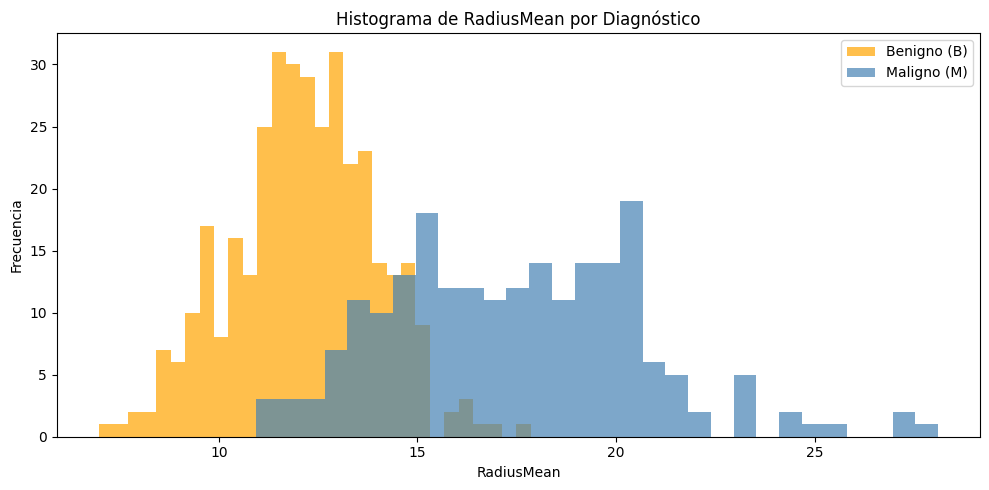

In [68]:
plt.figure(figsize=(10, 5))

# Naranja para B (Benigno), Azul para M (Maligno) — según el lab
df[df['Diagnosis'] == 'B']['RadiusMean'].plot.hist(
    bins=30, color='orange', alpha=0.7, label='Benigno (B)')
df[df['Diagnosis'] == 'M']['RadiusMean'].plot.hist(
    bins=30, color='steelblue', alpha=0.7, label='Maligno (M)')

plt.title('Histograma de RadiusMean por Diagnóstico')
plt.xlabel('RadiusMean')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

### Paso 11 — Gráficos de violín para múltiples características


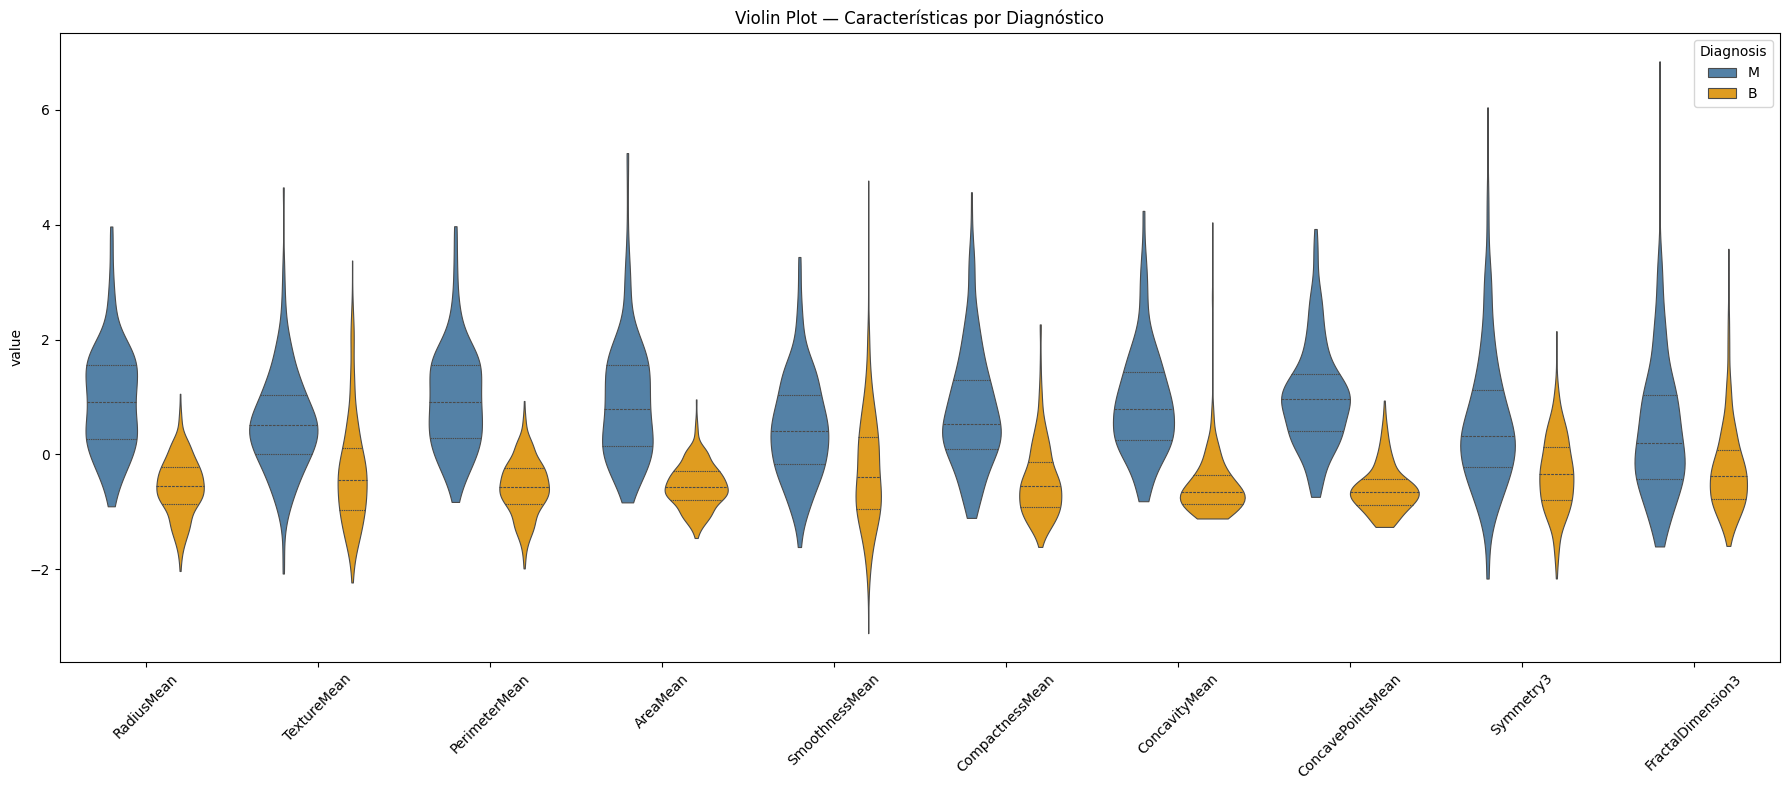

In [69]:
%matplotlib inline

# Columnas exactas del enunciado del lab
features_violin = ['Diagnosis',
                   'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean',
                   'SmoothnessMean', 'CompactnessMean', 'ConcavityMean',
                   'ConcavePointsMean', 'Symmetry3', 'FractalDimension3']

# Usar df_norm para que las escalas sean comparables entre columnas
data_melt = pd.melt(df_norm[features_violin],
                    id_vars='Diagnosis',
                    var_name='features',
                    value_name='value')

fig, ax = plt.subplots(figsize=(18, 8))

sns.violinplot(x='features', y='value', hue='Diagnosis',
               data=data_melt,
               inner='quart',
               dodge='auto',
               palette={'B': 'orange', 'M': 'steelblue'},
               cut=0,
               linewidth=0.8,
               ax=ax)

plt.xticks(rotation=45)
ax.set_title('Violin Plot — Características por Diagnóstico')
ax.set_xlabel('')
fig.tight_layout()
plt.show()

### Paso 12 — Determinar y eliminar outliers en RadiusMean

#### 12a — Boxplot para identificar outliers visualmente

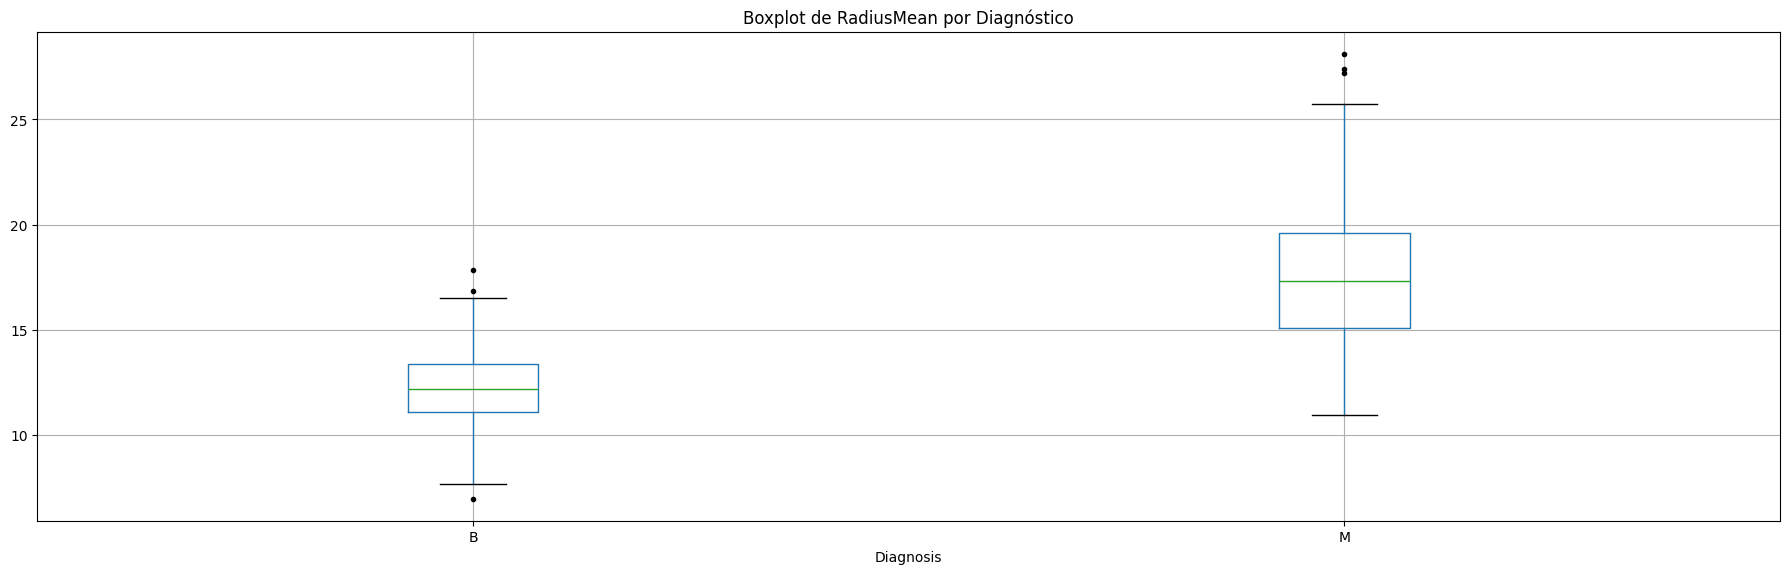

In [70]:
# Código exacto del lab
df.boxplot(column='RadiusMean', by='Diagnosis', sym='k.', figsize=(18, 6))
plt.suptitle('')
plt.title('Boxplot de RadiusMean por Diagnóstico')
plt.tight_layout()
plt.show()

#### 12b — Eliminar outliers con IQR (Rango Intercuartilico)

In [71]:
print(f'Filas antes de filtrar: {len(df)}')

Q1  = df['RadiusMean'].quantile(0.25)
Q3  = df['RadiusMean'].quantile(0.75)
IQR = Q3 - Q1

# El lab dice: df = df[~(...)]  — se sobreescribe df
df = df[~((df['RadiusMean'] < (Q1 - 1.5 * IQR)) |
          (df['RadiusMean'] > (Q3 + 1.5 * IQR)))]

print(f'Filas después de eliminar outliers IQR: {len(df)}')

Filas antes de filtrar: 569
Filas después de eliminar outliers IQR: 555


#### 12c — Alternativa con Z-score

In [72]:
from scipy import stats

# El lab dice: df = df[(np.abs(stats.zscore(...)) < 3)]
df = df[(np.abs(stats.zscore(df['RadiusMean'])) < 3)]

print(f'Filas después de Z-score: {len(df)}')

Filas después de Z-score: 555


### Paso 13 — Matriz de correlación con corr() y heatmap()

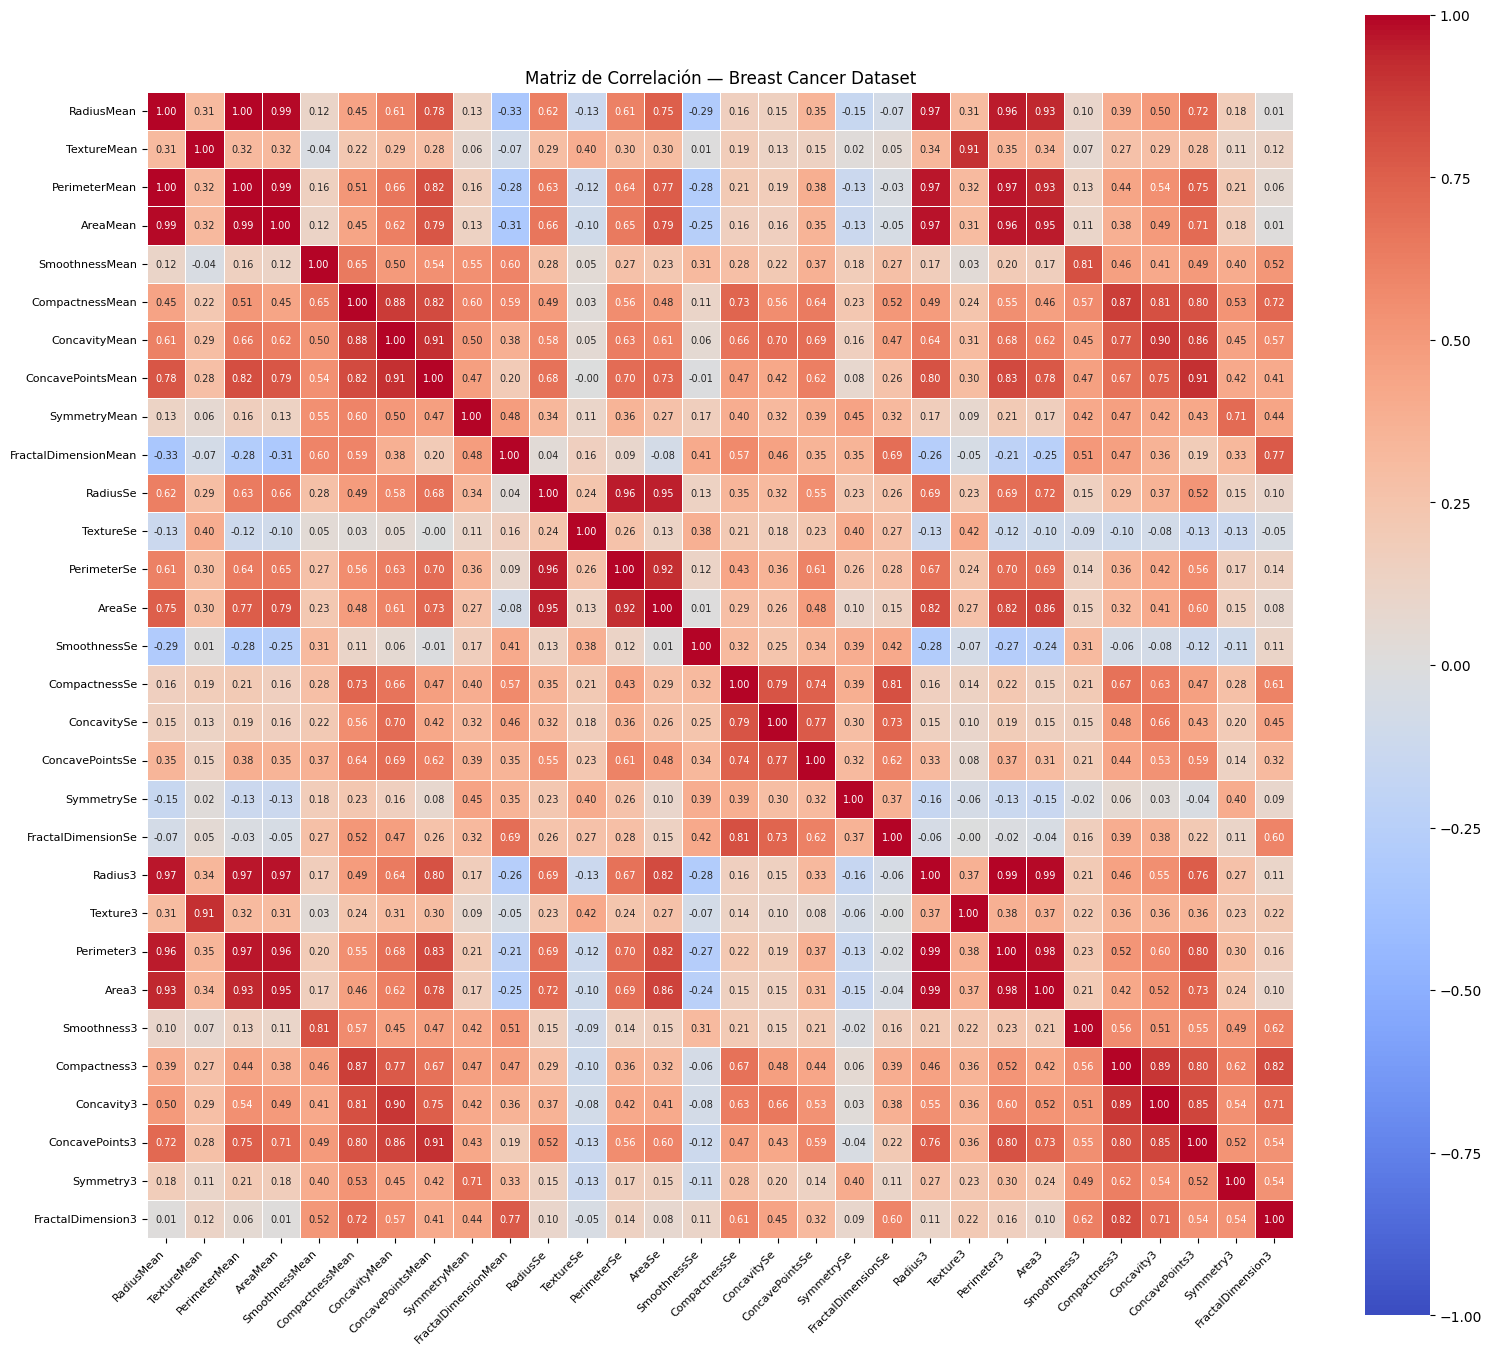

In [73]:
# Calcular la matriz de correlación solo con columnas de características
cols_excluir  = ['Id', 'Diagnosis', 'DiagnosisNumeric']
cols_features = [c for c in df.columns if c not in cols_excluir]

corr_matrix = df[cols_features].corr()

# Graficar con heatmap de seaborn
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.4,
            annot_kws={'size': 7})
plt.title('Matriz de Correlación — Breast Cancer Dataset')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Paso 14 — ¿Qué otros gráficos pueden realizarse para entender mejor los datos?

Se proponen tres gráficos adicionales: pairplot, KDE plot y scatter plot.

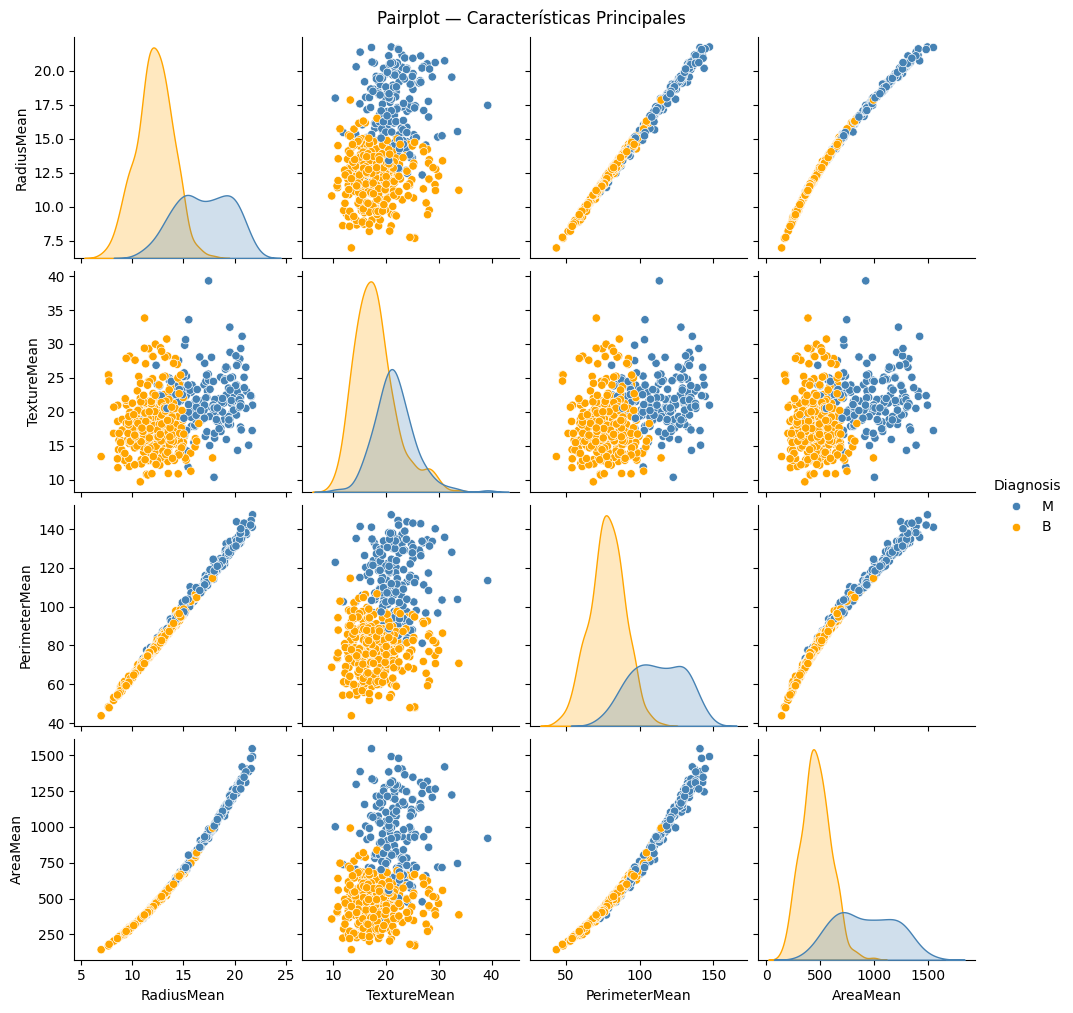

In [74]:
# Pairplot — relaciones entre pares de características
cols_pair = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'Diagnosis']
sns.pairplot(df[cols_pair], hue='Diagnosis',
             palette={'B': 'orange', 'M': 'steelblue'},
             diag_kind='kde')
plt.suptitle('Pairplot — Características Principales', y=1.01)
plt.show()

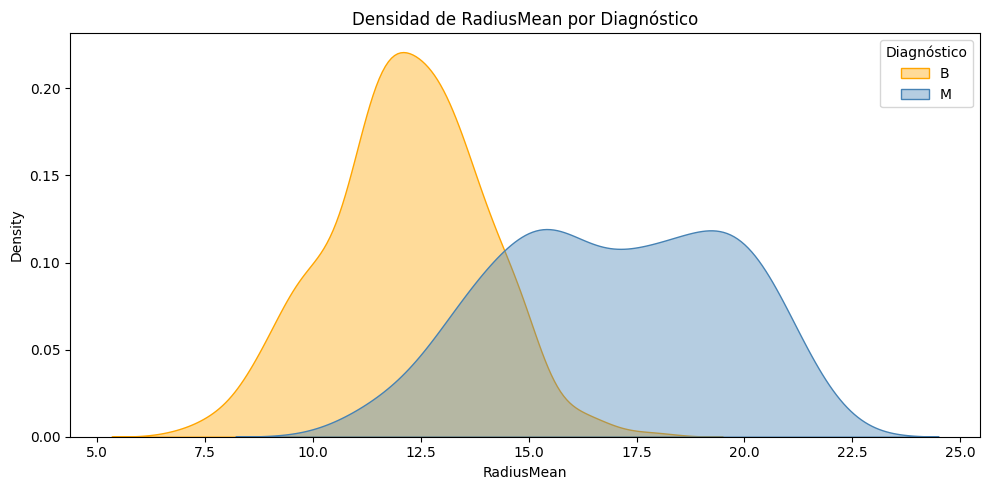

In [75]:
# KDE plot — densidad de probabilidad por clase
plt.figure(figsize=(10, 5))
for diag, color in [('B', 'orange'), ('M', 'steelblue')]:
    sns.kdeplot(data=df[df['Diagnosis'] == diag]['RadiusMean'],
                fill=True, alpha=0.4, label=diag, color=color)
plt.title('Densidad de RadiusMean por Diagnóstico')
plt.xlabel('RadiusMean')
plt.legend(title='Diagnóstico')
plt.tight_layout()
plt.show()

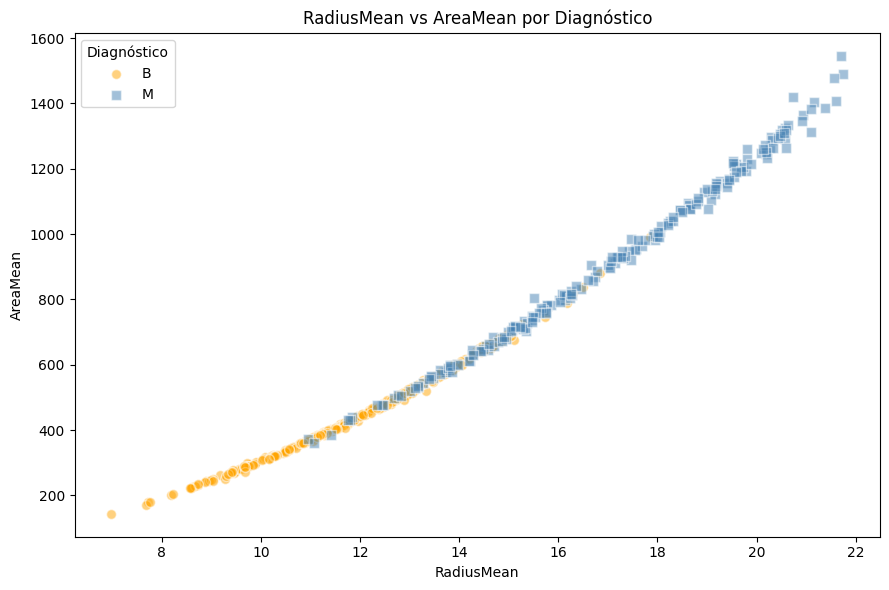

In [76]:
# Scatter plot — dos variables coloreadas por clase
plt.figure(figsize=(9, 6))
for diag, color, marker in [('B', 'orange', 'o'), ('M', 'steelblue', 's')]:
    mask = df['Diagnosis'] == diag
    plt.scatter(df.loc[mask, 'RadiusMean'], df.loc[mask, 'AreaMean'],
                c=color, alpha=0.5, edgecolors='white', s=50,
                marker=marker, label=diag)
plt.xlabel('RadiusMean')
plt.ylabel('AreaMean')
plt.title('RadiusMean vs AreaMean por Diagnóstico')
plt.legend(title='Diagnóstico')
plt.tight_layout()
plt.show()